# Phase 1
---
### Introduction:
Liver disease is one of the most preventable yet underdiagnosed conditions worldwide. When caught early, treatment is far more effective, but in many settings, access to specialist care and timely diagnosis remains limited. This project explores how machine learning can bridge that gap by building a predictive model that identifies liver disease using routine blood test results.
No extra costs, no specialist required at the first step. Just a smarter way to flag who needs a closer look.
We're working with the Indian Liver Patient Dataset (ILPD), which contains records from 583 real patients collected at a hospital in North-East Andhra Pradesh, India. Each record includes 10 blood-based measurements alongside a label: liver disease or not.
This notebook is Phase 1 of our project. Before we build anything, we want to actually understand what we're working with, how the data is structured, what the features look like, and what relationships exist between variables. The insights gathered here will directly inform our preprocessing and modeling decisions in later phases.

---
## Part A: Problem Understanding and Data Exploration
---

## 1. Problem Definition & Motivation

### 1.1 Problem Statement

Liver disease has quietly become one of the world's most serious health crises. Driven by rising rates of alcohol consumption, hepatitis infections, and obesity, it now ranks among the leading causes of death globally and the numbers keep climbing. What makes this especially troubling is the gap between early and late diagnosis. Catch it early, and there's a real chance to intervene. Miss that window, and the options shrink dramatically. Yet the blood tests, imaging, and specialist visits needed to make that call are often costly, time-consuming, and simply out of reach for many people. That's the problem we're trying to address. By applying machine learning to patient demographics and routine blood test results, we want to build a model that can predict whether someone has liver disease before it's too late. Not as a replacement for medical expertise, but as a first line of screening: fast, accessible, and practical enough to work

### 1.2 Motivation

There are a few reasons why we think this is a worthwhile problem to work on:

- **It can save lives.** If we catch liver disease early, the chances of successful treatment go way up.
- **It helps where doctors are scarce.** Not every clinic has a liver specialist, so an automated tool could help fill that gap.
- **There's a gender gap in diagnosis.** Some studies show that women tend to get diagnosed later than men, so we want to look into that in our data.
- **It uses tests that are already done.** The features we're working with (blood markers) are part of routine checkups, so there's no extra cost for the patient.

### 1.3 The Dataset Goal

This is basically a **binary classification** task. We're trying to predict one of two outcomes:

- **Class 1:** The patient has liver disease.
- **Class 2:** The patient does not have liver disease.

## 2. Dataset Selection & Justification

### 2.1 Dataset Source

We're using the **Indian Liver Patient Dataset (ILPD)**, which is available on both the UCI Machine Learning Repository and Kaggle.

- **Link:** https://www.kaggle.com/datasets/uciml/indian-liver-patient-records
- **Total records:** 583 patients
- **Features:** 10 input features + 1 target column
- **Collected from:** North-East Andhra Pradesh, India

### 2.2 Why This Dataset?

We chose this dataset for our problem for a few key reasons. One, it's made up of real patient data collected from an actual hospital in Andhra Pradesh, India not synthetic or simulated records. That matters because it means the patterns our model picks up on reflect how liver disease actually presents in real clinical settings.
Seconde, The features also made a lot of sense for our use case. All 10 input variables are standard blood test results and liver enzyme measurements things like bilirubin levels, albumin, and SGPT that doctors genuinely rely on when diagnosing liver conditions. So there's a clear, direct connection between the data and the problem we're trying to solve.
Third, the target variable is also straightforward, each patient is simply labeled as having liver disease or not, which makes this a clean binary classification task with no ambiguity around what we're predicting.
One thing we found particularly interesting is the class imbalance in the data  about 71% of patients have liver disease, while 29% are healthy. Rather than seeing this as a drawback, we saw it as realistic. People who show up for liver-related testing are more likely to be ill, so this distribution actually reflects real-world conditions and gives us a chance to properly work through imbalance-handling techniques like oversampling or class weighting.
Finally, the dataset is nearly complete, with only 4 missing values across a single column out of 583 records, minimizing the risk of data quality issues skewing our results.


## 3. Exploratory Data Analysis (EDA)

Before jumping into any modeling, we need to actually understand what's in the data. This section goes through the key patterns, distributions, and relationships in the dataset.

### 3.1 Feature Description

| # | Feature | Type | Unit | Clinical Meaning |
|---|---------|------|------|------------------|
| 1 | Age | Numeric | Years | Patient age |
| 2 | Gender | Categorical | — | Male / Female |
| 3 | Total_Bilirubin | Numeric | mg/dL | Byproduct of red blood cell breakdown |
| 4 | Direct_Bilirubin | Numeric | mg/dL | Conjugated bilirubin processed by liver |
| 5 | Alkaline_Phosphotase | Numeric | IU/L | Enzyme found in liver and bones |
| 6 | Alamine_Aminotransferase | Numeric | IU/L | ALT - liver-specific enzyme |
| 7 | Aspartate_Aminotransferase | Numeric | IU/L | AST - enzyme in liver, heart, muscles |
| 8 | Total_Protiens | Numeric | g/dL | Total serum protein level |
| 9 | Albumin | Numeric | g/dL | Major blood protein made by liver |
| 10 | Albumin_and_Globulin_Ratio | Numeric | — | A/G ratio (liver function indicator) |
| **Target** | Dataset | Binary | — | 1 = Liver patient, 2 = Non-liver patient |

### 3.2 Loading and Inspecting the Dataset

We will start by loading the data to perform feature analysis and taking a quick look at what we're working with.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('Dataset/indian_liver_patient.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 583 rows x 11 columns


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


In [8]:
df.describe().round(2)

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.00,583.00,583.00,583.00,583.00,583.00,583.00,583.00,579.00,583.00
mean,44.75,3.30,1.49,290.58,80.71,109.91,6.48,3.14,0.95,1.29
std,16.19,6.21,2.81,242.94,182.62,288.92,1.09,0.80,0.32,0.45
min,4.00,0.40,0.10,63.00,10.00,10.00,2.70,0.90,0.30,1.00
25%,33.00,0.80,0.20,175.50,23.00,25.00,5.80,2.60,0.70,1.00
50%,45.00,1.00,0.30,208.00,35.00,42.00,6.60,3.10,0.93,1.00
75%,58.00,2.60,1.30,298.00,60.50,87.00,7.20,3.80,1.10,2.00
max,90.00,75.00,19.70,2110.00,2000.00,4929.00,9.60,5.50,2.80,2.00


### 3.3 Target Variable Distribution

First thing we want to check is how balanced (or imbalanced) the target classes are.

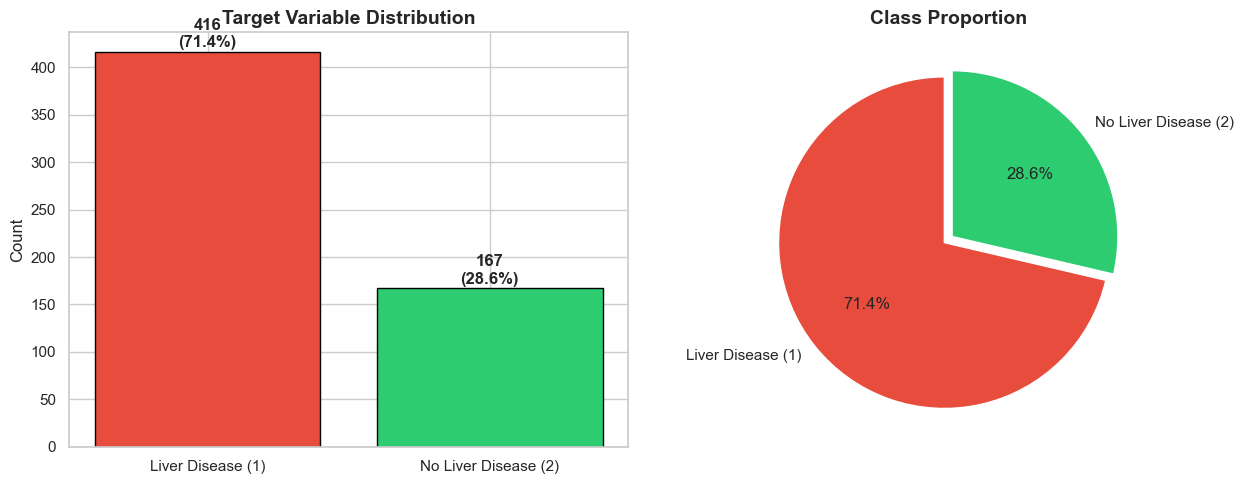

Liver Disease: 416 (71.4%)
Non-Liver Disease: 167 (28.6%)
Imbalance ratio: 2.49:1


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df['Dataset'].value_counts()
labels = ['Liver Disease (1)', 'No Liver Disease (2)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.03, 0.03))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Liver Disease: {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
print(f'Non-Liver Disease: {counts[2]} ({counts[2]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {counts[1]/counts[2]:.2f}:1')

So clearly the dataset is imbalanced, about 71% of the patients have liver disease and only 29% don't. That's roughly a 2.5:1 ratio.

### 3.4 Gender Distribution

We will see how gender is distributed and whether it has any relationship with liver disease.

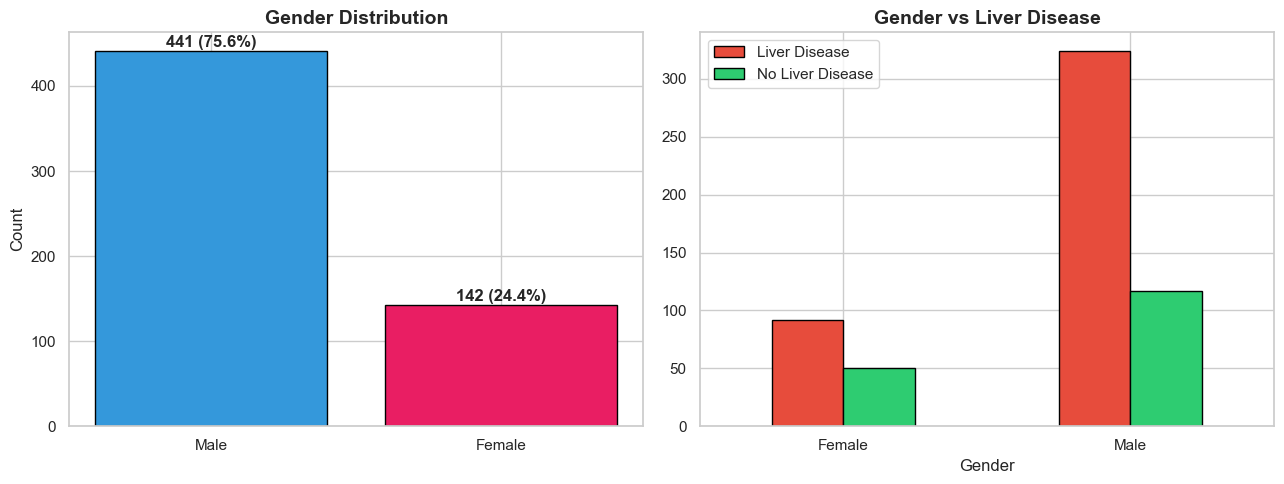

Dataset    1    2  All
Gender                
Female    92   50  142
Male     324  117  441
All      416  167  583


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
gc = df['Gender'].value_counts()
axes[0].bar(['Male','Female'], gc.values, color=['#3498db','#e91e63'], edgecolor='black')
for i, v in enumerate(gc.values):
    axes[0].text(i, v+5, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

ct = pd.crosstab(df['Gender'], df['Dataset'])
ct.columns = ['Liver Disease', 'No Liver Disease']
ct.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[1].set_title('Gender vs Liver Disease', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(pd.crosstab(df['Gender'], df['Dataset'], margins=True))

There are way more males (441, about 75.6%) than females (142, about 24.4%) in the dataset. Among males, around 73.5% have liver disease, while for females it's about 64.8%. So males seem to be slightly more likely to have liver disease in this dataset, but the gender imbalance itself is something to be aware of.

### 3.5 Age Distribution by Class

We will see how age is distributed and whether it has any relationship with liver disease.

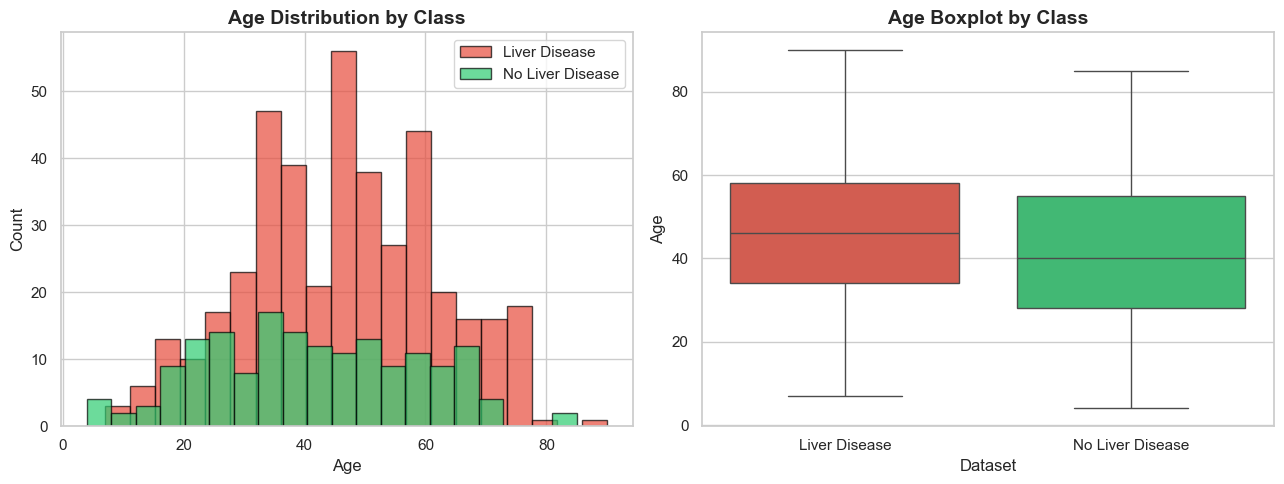

         count   mean    std  min   25%   50%   75%   max
Dataset                                                  
1        416.0  46.15  15.65  7.0  34.0  46.0  58.0  90.0
2        167.0  41.24  17.00  4.0  28.0  40.0  55.0  85.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df[df['Dataset']==1]['Age'].hist(bins=20, ax=axes[0], color='#e74c3c',
                                  alpha=0.7, label='Liver Disease', edgecolor='black')
df[df['Dataset']==2]['Age'].hist(bins=20, ax=axes[0], color='#2ecc71',
                                  alpha=0.7, label='No Liver Disease', edgecolor='black')
axes[0].set_title('Age Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count'); axes[0].legend()

sns.boxplot(x='Dataset', y='Age', data=df, ax=axes[1], palette=['#e74c3c','#2ecc71'])
axes[1].set_xticklabels(['Liver Disease','No Liver Disease'])
axes[1].set_title('Age Boxplot by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('Dataset')['Age'].describe().round(2))

The age distribution looks pretty similar for both classes. Both groups have a mean age around 44-45 years. The range goes from 4 years old all the way up to 90, so the dataset covers a wide age range. Age alone probably won't be a strong differentiator between the two classes.

### 3.6 Feature Distributions by Class
We will look at how each blood test feature is distributed, split by liver disease vs. no liver disease.

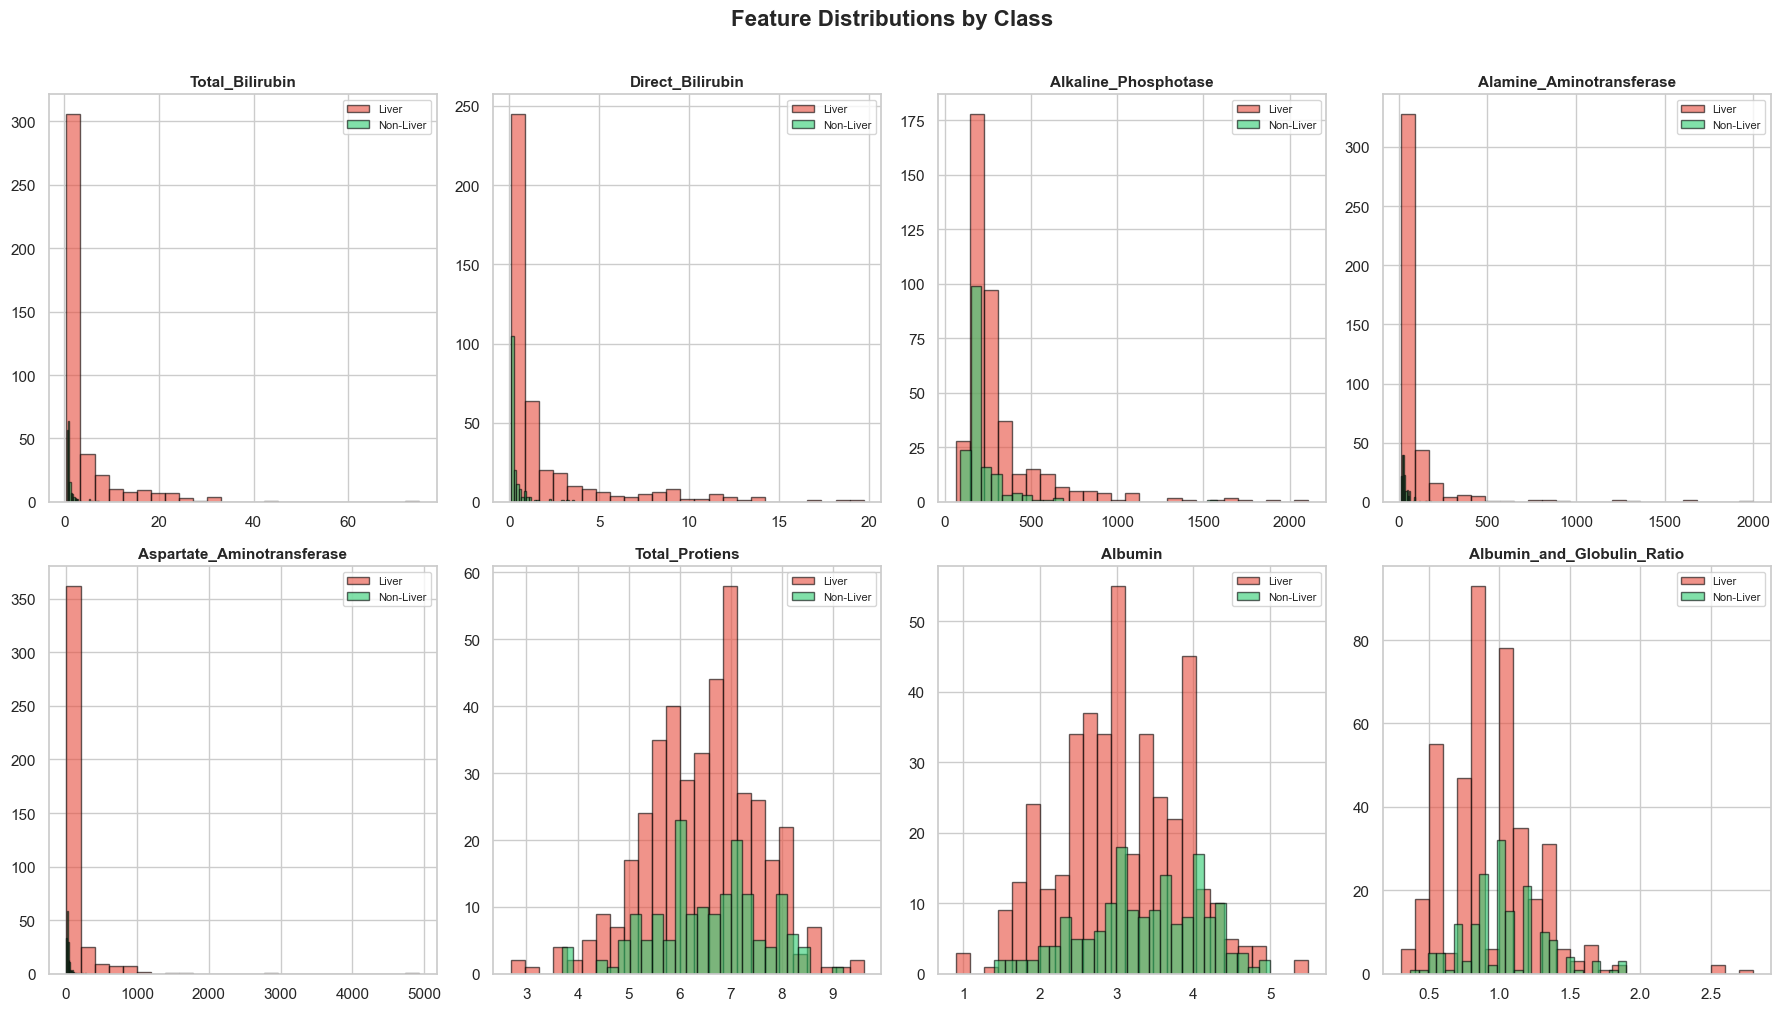

In [16]:
num_cols = ['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
            'Alamine_Aminotransferase', 'Aspartate_Aminotransferase',
            'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df[df['Dataset']==1][col].hist(bins=25, ax=axes[i], color='#e74c3c',
                                    alpha=0.6, label='Liver', edgecolor='black')
    df[df['Dataset']==2][col].hist(bins=25, ax=axes[i], color='#2ecc71',
                                    alpha=0.6, label='Non-Liver', edgecolor='black')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

fig.suptitle('Feature Distributions by Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

A few things stand out here:
- Bilirubin (both Total and Direct) is heavily right-skewed, and liver patients tend to have higher values.
- The enzyme levels (ALT, AST, ALP) are also very skewed with some extreme values.
- On the other hand, Total Proteins, Albumin, and the A/G Ratio look more like normal distributions.
- Interestingly, liver patients seem to have lower Albumin and A/G Ratio, which makes sense medically since a damaged liver produces less albumin.

### 3.7 Boxplots, Outlier Detection

Boxplots are good for spotting outliers and seeing how the spread compares between the two groups.

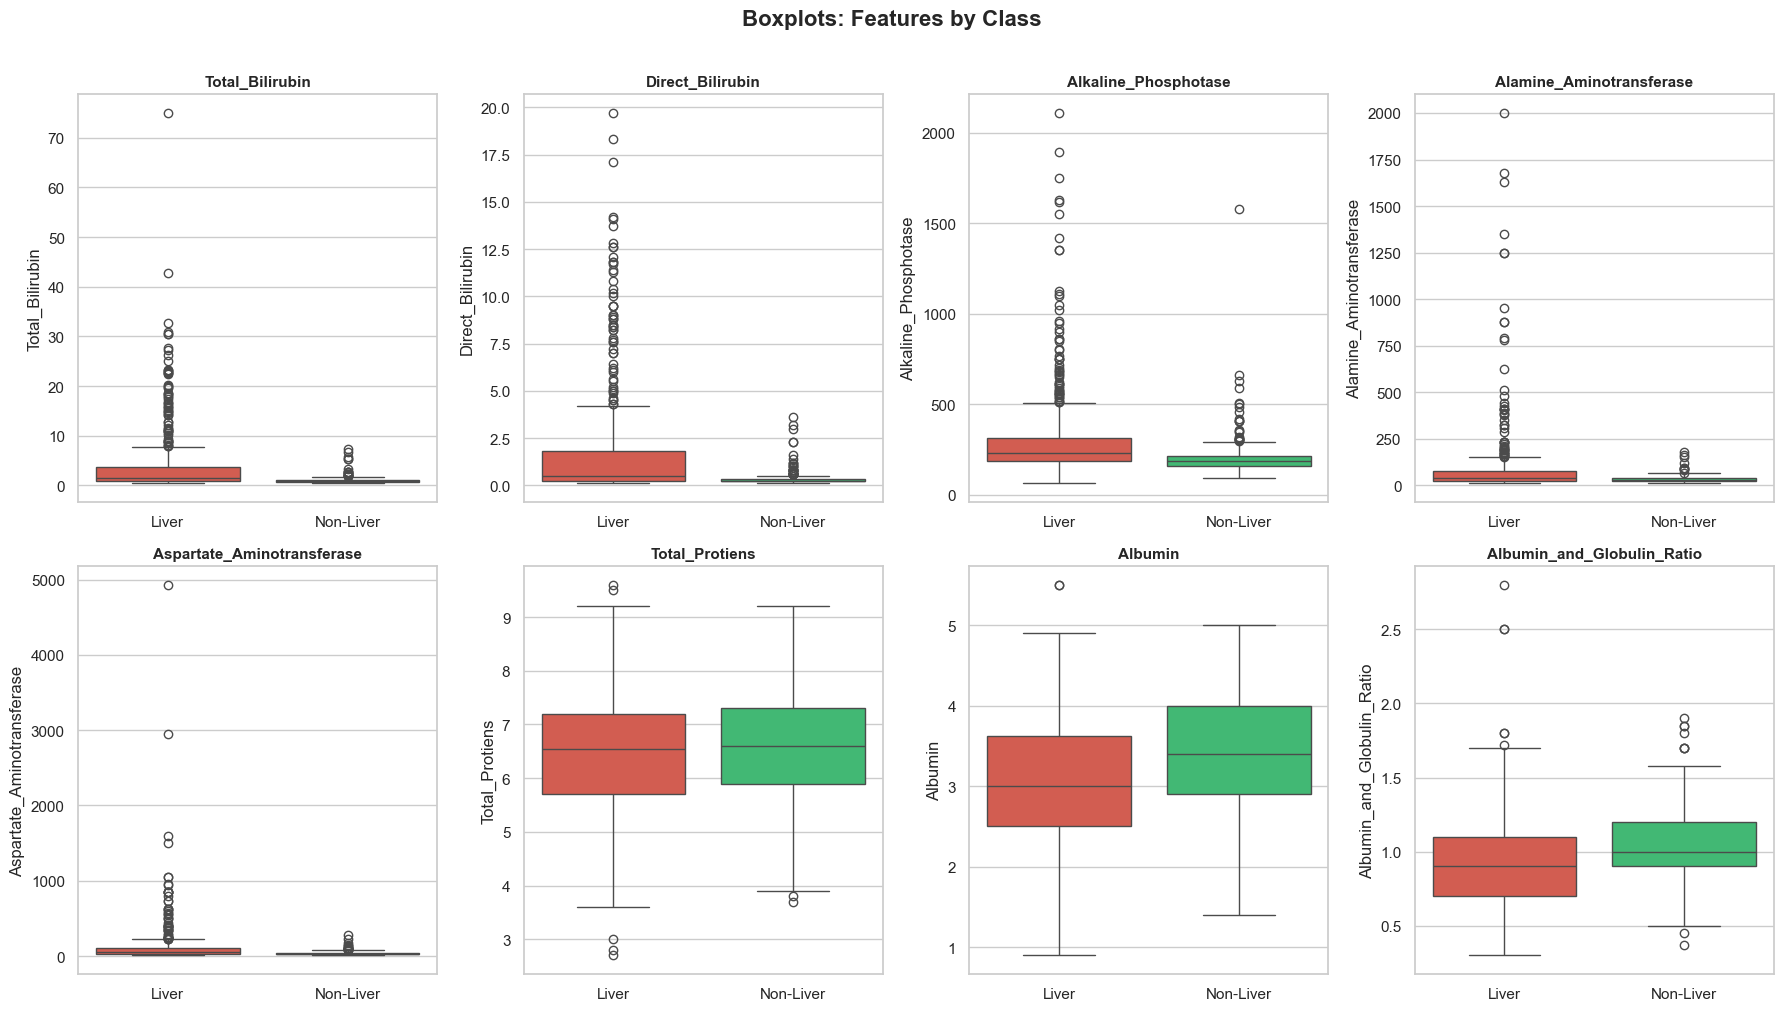

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Dataset', y=col, data=df, ax=axes[i], palette=['#e74c3c','#2ecc71'])
    axes[i].set_xticklabels(['Liver','Non-Liver'])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

fig.suptitle('Boxplots: Features by Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

There are a lot of outliers in the enzyme and bilirubin features. But these aren't data errors. In a medical context, extremely high enzyme levels usually mean the liver is seriously damaged. So we shouldn't just remove them, they actually carry important information.

### 3.8 Detailed Correlation Heatmap

We will check how the features correlate with each other and with the target. This helps us spot multicollinearity (features that basically say the same thing).

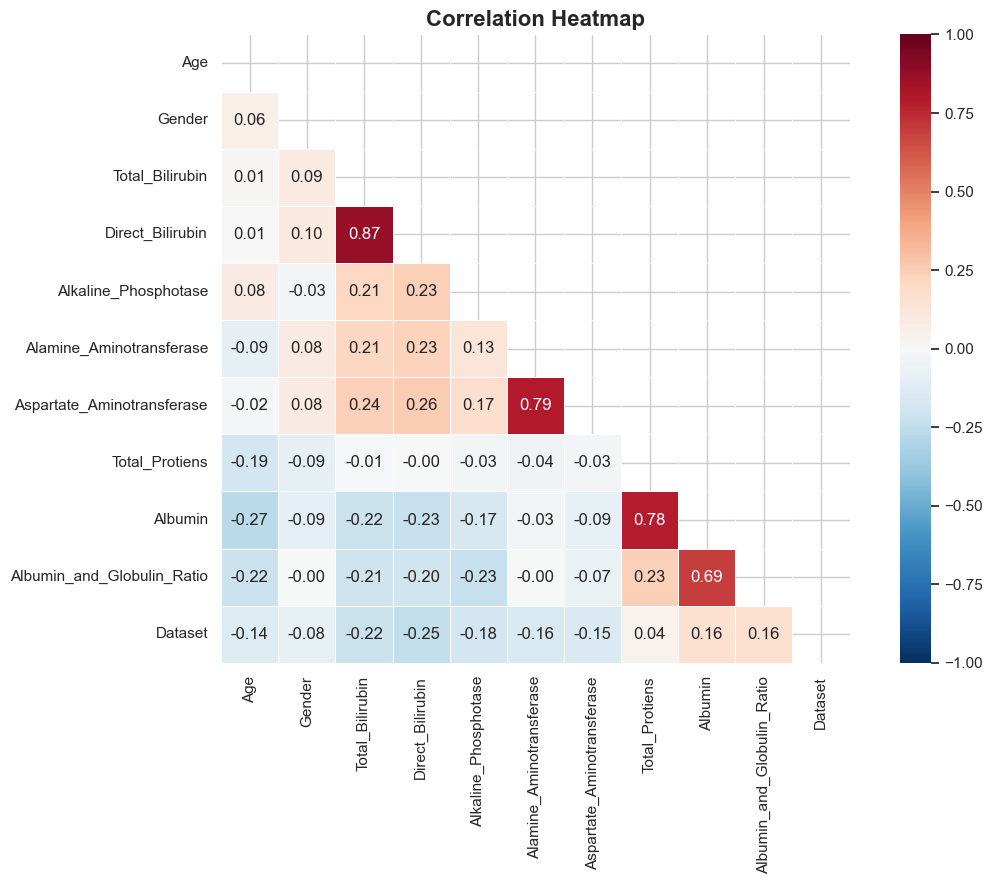

Strong correlations (|r| > 0.5):
  Total_Bilirubin <-> Direct_Bilirubin: 0.875
  Alamine_Aminotransferase <-> Aspartate_Aminotransferase: 0.792
  Total_Protiens <-> Albumin: 0.784
  Albumin <-> Albumin_and_Globulin_Ratio: 0.690


In [20]:
df_enc = df.copy()
df_enc['Gender'] = df_enc['Gender'].map({'Male': 1, 'Female': 0})
corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Strong correlations (|r| > 0.5):')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.5:
            print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i,j]:.3f}')

Some strong correlations here that make sense:
- **Total Bilirubin & Direct Bilirubin** (r ~ 0.87) - not surprising since direct bilirubin is part of total bilirubin.
- **ALT & AST** - both are liver enzymes that go up when the liver is damaged.
- **Total Proteins & Albumin** - albumin makes up a big chunk of total proteins.

---
## 2 Preprocessing & Visualization Team
---

### Loading the Dataset

In this step, we import the required library (Pandas) and load the dataset 
to begin exploring its structure and content.

The dataset used in this project is the Indian Liver Patient Records dataset.

### Initial Data Preview

We display the first few rows of the dataset to understand 
the structure, feature names, and example values.

This helps verify that the dataset has been loaded correctly.

In [22]:
import pandas as pd

df = pd.read_csv("Dataset/indian_liver_patient.csv")

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


### Dataset Structure and Data Types

In this step, we inspect the dataset structure using df.info() 
to identify:

- Number of records
- Number of features
- Data types of each column
- Presence of missing values

Understanding data types is important before performing preprocessing.

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


Observation:

The dataset contains 583 records and 11 features.

Most of the variables are numerical (int64 and float64), 
while the "Gender" column is categorical (object type).

There appear to be minimal missing values in the dataset.

### Class Distribution Analysis

In this step, we visualize the distribution of the target variable (Dataset) 
to understand the balance between the two classes:

1 → Patients with Liver Disease  
2 → Patients without Liver Disease  

This helps determine whether the dataset is balanced or imbalanced, 
which is important for future modeling steps.

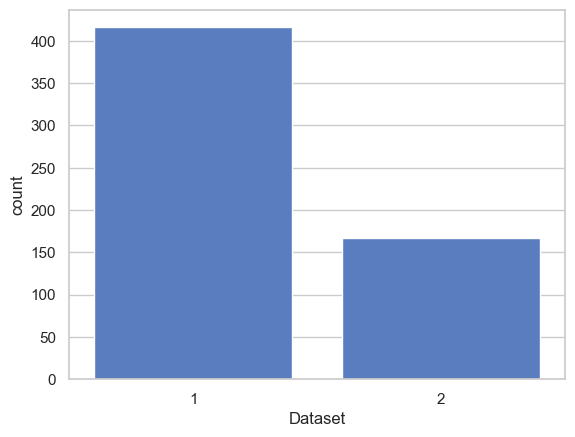

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Dataset',data=df)
plt.show()

Observation:

The majority of the records belong to class 1 (Liver Disease), 
while class 2 (No Liver Disease) contains fewer samples.

This indicates that the dataset is slightly imbalanced, 
which may affect model performance in later phases.

### Correlation Analysis

In this step, we analyze the relationships between numerical features 
using a correlation heatmap.

The correlation matrix helps identify:
- Strong positive relationships
- Strong negative relationships
- Potential redundant features
- Relationships between features and the target variable

Only numerical features are included in this analysis.

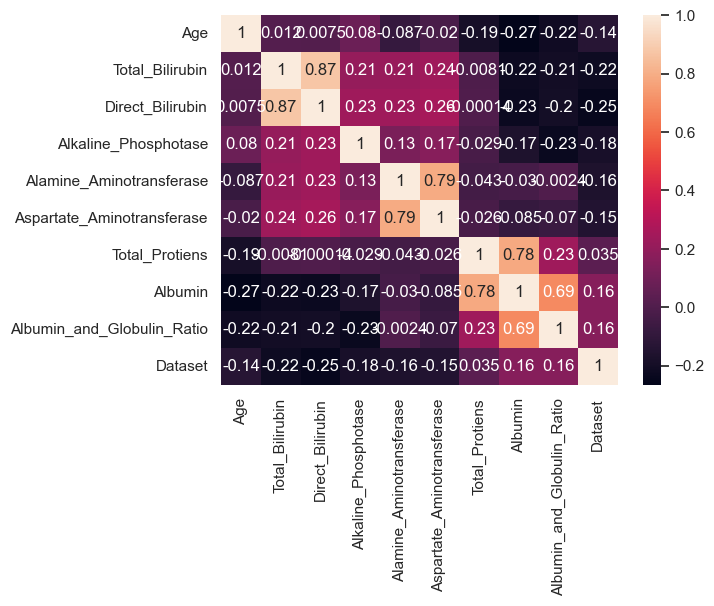

In [25]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)
plt.show()

Observation:

The heatmap shows moderate correlations between some liver enzyme indicators 
such as Total_Bilirubin and Direct_Bilirubin.

Some features appear strongly related, which may indicate 
that they capture similar medical information.

The target variable (Dataset) shows weak to moderate correlations 
with certain features, suggesting that multiple attributes 
contribute to liver disease detection.

### Feature Distribution Analysis

In this step, we visualize the distribution of all numerical features 
using histograms.

This helps us understand:

- The range of values
- Skewness of the data
- Presence of outliers
- Whether features follow normal distribution

Understanding feature distributions is important before applying 
any preprocessing or modeling techniques.

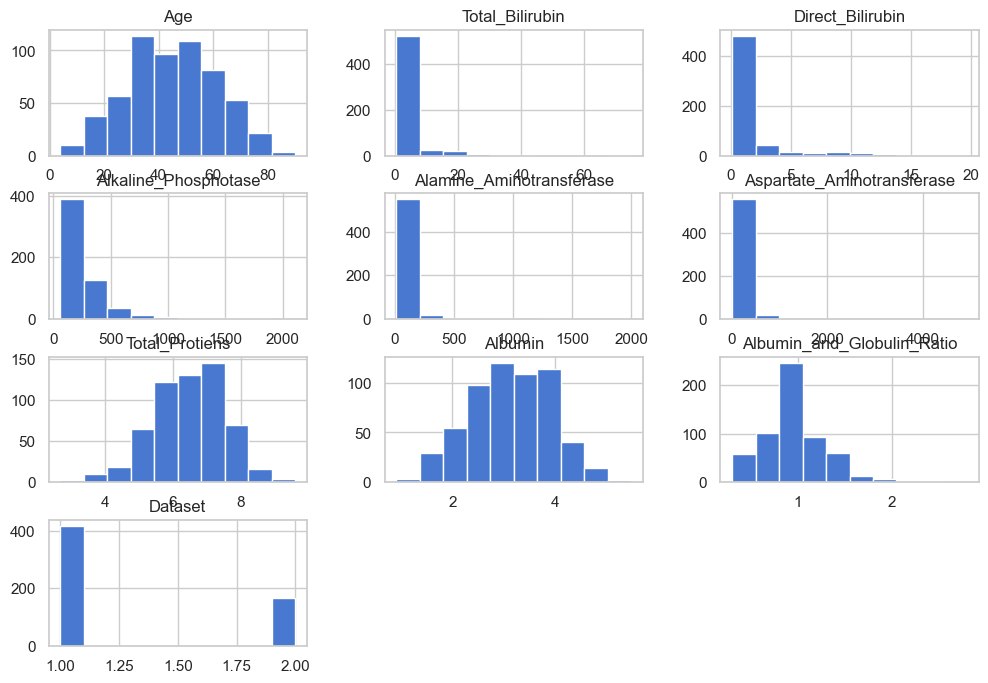

In [26]:
df.select_dtypes(include="number").hist(figsize=(12,8))
plt.show()

Observation:

Several features such as Total_Bilirubin, Direct_Bilirubin, 
and liver enzyme indicators show right-skewed distributions, 
indicating the presence of extreme values.

Some features such as Age and Total_Proteins appear more normally distributed.

These observations suggest that scaling or transformation 
may be required in later modeling phases.

Note:
Only numerical features were included in this visualization.
Categorical variables such as Gender were excluded.

### Missing Values Analysis

In this step, we check for missing values in each feature 
using df.isnull().sum().

Identifying missing values is essential before preprocessing, 
as incomplete data may negatively affect model performance.

In [27]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Observation:

Most features contain no missing values.

However, the feature "Albumin_and_Globulin_Ratio" 
contains a small number of missing values.

Since this feature is numerical, an appropriate imputation strategy 
is required to handle the missing entries.

### Handling Missing Values

To handle missing values in the "Albumin_and_Globulin_Ratio" feature, 
we use median imputation.

The median is chosen instead of the mean because 
the distribution of this feature is slightly skewed, 
and the median is more robust to outliers.

In [28]:
df["Albumin_and_Globulin_Ratio"] = df["Albumin_and_Globulin_Ratio"].fillna(
    df["Albumin_and_Globulin_Ratio"].median()
)

In [29]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

Observation:

After applying median imputation, 
there are no remaining missing values in the dataset.

The dataset is now complete and ready for further preprocessing steps.

### Encoding Categorical Variables

Machine learning models require numerical input.
Therefore, we convert the categorical variable "Gender" 
into numerical format.

Mapping strategy:
Male → 1  
Female → 0

This transformation allows the feature to be used in 
correlation analysis and future modeling steps.

In [30]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [31]:
df["Gender"].value_counts()

Gender
1    441
0    142
Name: count, dtype: int64

Observation:

After encoding, the Gender feature is now represented numerically.

The distribution shows that the majority of patients are male, 
which may influence the dataset characteristics.

### Duplicate Records Check

In this step, we check for duplicate records 
to ensure data quality.

Duplicate entries may bias model training 
and lead to inaccurate results.

In [32]:
df.duplicated().sum()

np.int64(13)

Observation:

The dataset contains 13 duplicate records.

These duplicates must be removed 
to maintain data integrity.

### Removing Duplicate Records

We remove duplicate rows from the dataset 
to ensure each record represents a unique patient.

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.duplicated().sum()

np.int64(0)

Observation:

After removing duplicates, no duplicate records remain.

The dataset is now clean and ready for modeling.

In [35]:
df.to_csv("preprocessed_data.csv", index=False)
print("Saved successfully")

Saved successfully


### Preprocessed Dataset Ready for Modeling

After completing data cleaning and preprocessing steps, the dataset is now prepared for machine learning modeling.

The following preprocessing steps were applied:

- Handled missing values by replacing them with the median.
- Converted categorical variable (Gender) into numerical format.
- Removed duplicate records to ensure data integrity.
- Verified data types and structure consistency.

The dataset is now clean, structured, and suitable for training classification models.